# Silicon Solar Cell Device Simulation

### MICS3090 (L01) · Integrated Circuit Devices

本教程以 **DEVSIM** 和一维 **p⁺-on-n 硅太阳能电池**为例，连接器件物理、数值求解、实验数据处理与参数校准。它面向本科二年级学生：重点是建立可解释的工作流，而不是复制工业 TCAD 的全部复杂度。

> **主线：** 结构与方程 → Newton 求解 → 内部物理量 → J–V 特性 → 数据处理 → 参数校准 → 可辨识性


## 1. 学习目标与使用方式

完成后，你应能：

1. 说明 p⁺ 发射极、n 型基区、光入射方向及电流符号；
2. 将 Poisson 方程、载流子连续性方程和 Newton 迭代联系起来；
3. 从 DEVSIM 解中读取掺杂、电势、电场、载流子和光生率；
4. 从 J–V 曲线提取 $J_{sc}$、$V_{oc}$、FF 和最大功率；
5. 区分原始 I–V、处理后的 J–V、合成数据和历史实验数据；
6. 用 Cell #3 的 light/dark J–V、light $J_{sc}$ 与 light $V_{oc}$ 完成联合校准，并判断参数是否可辨识。

建议先按顺序运行全部单元，再修改 `config.py` 中少量参数做对照实验。Notebook 中所有图都由当前代码生成，不依赖预置截图。


## 2. 环境与项目入口

下面的设置单元会自动找到项目根目录。核心入口很少：`config.py` 保存教学基线，`model/` 实现前向模型，`calibration/` 负责拟合与诊断，`data/raw/` 和 `data/processed/` 分别保存仪器原始导出与标准化数据。


In [1]:
import os
import sys
from pathlib import Path

start = Path.cwd().resolve()
project_root = next(
    (path for path in (start, *start.parents) if (path / "config.py").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from inside the project directory.")

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from config import CALIBRATION, MODEL_PARAMS, MODELED_INPUT_POWER_W_CM2
from model import check_params, profiles, run_simulation, simulate_eqe, terminal_iv
from model.analysis import band_edges, solar_metrics
from model.style import C_BLUE, C_DARK, C_GRAY, C_GREEN, C_ORANGE, apply_classroom_style

apply_classroom_style()
print("Project root detected.")
print("Notebook environment is ready.")


Project root detected.
Notebook environment is ready.


## 3. p⁺-on-n 结构与坐标约定

光从 $x=0$ 的前表面进入：先经过薄而重掺杂的 **p⁺ 发射极**，再进入较厚、较轻掺杂的 **n 型基区**。因此本项目不是 n-on-p，也不是 p 区位于背面。

| 量 | 本项目约定 |
|---|---|
| 位置 | 前表面 $x=0$；背表面 $x=W$ |
| 掺杂 | p⁺：$N_A>N_D$；n：$N_D>N_A$ |
| 净掺杂 | $N_D-N_A<0$（p⁺），$N_D-N_A>0$（n） |
| J–V 电流 | 发电方向为正，因此短路时 $J_{sc}>0$ |
| 正向电压 | 降低结势垒，使二极管暗电流抵消光生电流 |

“p⁺-on-n”描述器件层次；“generation-positive”描述绘图与校准使用的电流符号。二者不能混为一谈。


## 4. 控制方程、符号与模型边界

DEVSIM 联立求解电势 $\psi$、电子浓度 $n$ 和空穴浓度 $p$：

$$
\frac{d^2\psi}{dx^2}=-\frac{q}{\varepsilon_{Si}}
\left(p-n+N_D^+-N_A^-\right),
$$

$$
\frac{dJ_n}{dx}=q(R-G),\qquad
\frac{dJ_p}{dx}=-q(R-G),
$$

并采用漂移—扩散电流关系。$G(x)$ 来自多波长 Beer–Lambert 吸收，$R$ 包括 SRH + Auger 体复合；前/背表面复合用有限厚度的有效“dead layer”近似。

本模型是**教学模型**：一维、突变结、Boltzmann 统计、恒定低场迁移率、无带隙变窄、16 个光谱采样点、无横向电流与精细接触物理。`photon_flux` 是**有效光生强度比例**；只有用已校准辐照度建立映射后，才可将它称为 “sun”。


## 5. Newton 迭代：求解器为什么需要初值？

指数形式的 $n(\psi)$ 与 $p(\psi)$ 使 Poisson 方程成为非线性方程。Newton 法反复线性化 $F(\psi)=0$ 并更新解；阻尼回溯用于避免一步走得太远。下面用 NumPy 求一个简化 p⁺-on-n 结，并将“能带逐步收敛”和“残差下降”同步显示。为使纯 NumPy 示例简短稳定，它使用保持相同掺杂比的较低玩具掺杂值，不是 `config.py` 中的 DEVSIM 器件数值。


Newton converged in 12 states; built-in potential = 0.7156 V.


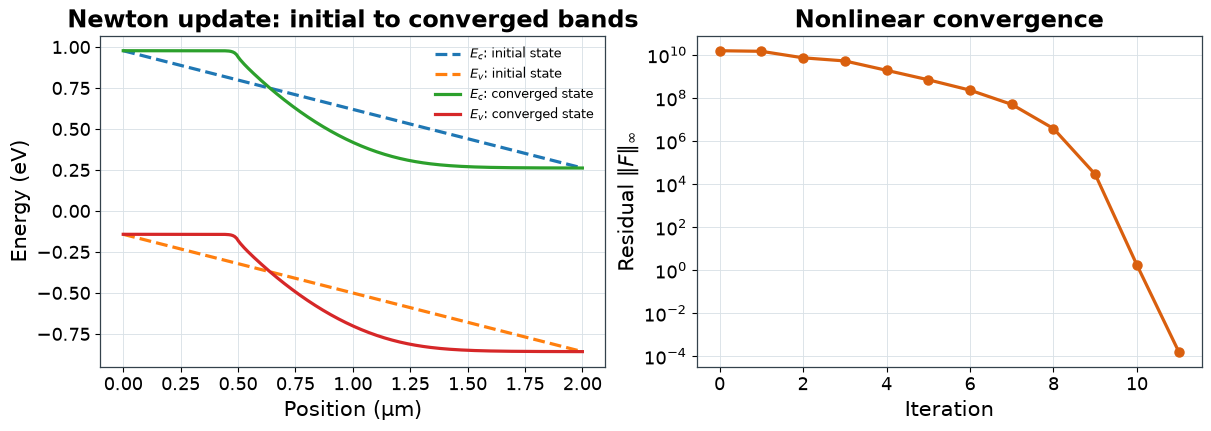

In [2]:
VT, NI = 0.0259, 1e10
q, eps0 = 1.602176634e-19, 8.854187817e-14
eps_si = 11.7 * eps0


def solve_tridiagonal(lower, diagonal, upper, right_hand_side):
    'Solve a tridiagonal linear system with the Thomas algorithm.'
    lower = lower.astype(float, copy=True)
    diagonal = diagonal.astype(float, copy=True)
    upper = upper.astype(float, copy=True)
    result = right_hand_side.astype(float, copy=True)
    for index in range(1, len(diagonal)):
        factor = lower[index - 1] / diagonal[index - 1]
        diagonal[index] -= factor * upper[index - 1]
        result[index] -= factor * result[index - 1]
    result[-1] /= diagonal[-1]
    for index in range(len(diagonal) - 2, -1, -1):
        result[index] = (result[index] - upper[index] * result[index + 1]) / diagonal[index]
    return result


def poisson_newton(x, net, psi_left, psi_right, max_iter=60, tol=1e-10):
    'Solve a 1D equilibrium Poisson problem with damped Newton iteration.'
    count, dx = len(x), x[1] - x[0]
    psi = psi_left + (psi_right - psi_left) * x / x[-1]
    history, residuals = [psi.copy()], []

    def equation(phi):
        electrons = NI * np.exp(phi / VT)
        holes = NI * np.exp(-phi / VT)
        charge_term = q / eps_si * (holes - electrons + net)
        value = np.zeros(count)
        value[1:-1] = (
            phi[:-2] - 2 * phi[1:-1] + phi[2:]
        ) / dx**2 + charge_term[1:-1]
        value[0], value[-1] = phi[0] - psi_left, phi[-1] - psi_right
        return value

    initial_residual = None
    for _ in range(max_iter):
        value = equation(psi)
        residual = float(np.max(np.abs(value)))
        residuals.append(residual)
        initial_residual = residual if initial_residual is None else initial_residual
        if residual < tol * initial_residual:
            break

        electrons = NI * np.exp(psi / VT)
        holes = NI * np.exp(-psi / VT)
        derivative = -(q / (eps_si * VT)) * (electrons + holes)
        inverse_dx2 = 1 / dx**2
        diagonal = -2 * inverse_dx2 + derivative
        lower = np.full(count - 1, inverse_dx2)
        upper = np.full(count - 1, inverse_dx2)
        diagonal[0] = diagonal[-1] = 1.0
        upper[0] = lower[-1] = 0.0
        step = solve_tridiagonal(lower, diagonal, upper, -value)

        damping = 1.0
        while damping >= 1e-8:
            trial = np.clip(psi + damping * step, -15, 15)
            if float(np.max(np.abs(equation(trial)))) < residual:
                break
            damping *= 0.5
        psi = trial
        history.append(psi.copy())
    return history, residuals


x_newton = np.linspace(0, 2e-4, 240)
net = np.where(x_newton < 0.5e-4, -1e17, 1e15)
psi_left = -VT * np.log(1e17 / NI)
psi_right = VT * np.log(1e15 / NI)
history, residuals = poisson_newton(x_newton, net, psi_left, psi_right)
built_in_voltage = history[-1][-1] - history[-1][0]
print(
    f"Newton converged in {len(history)} states; "
    f"built-in potential = {built_in_voltage:.4f} V."
)

band_gap = 1.12
fig, (ax_band, ax_residual) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for state, label, style in ((history[0], "initial state", "--"),
                            (history[-1], "converged state", "-")):
    ax_band.plot(x_newton * 1e4, -state + band_gap / 2, style, label=f"$E_c$: {label}")
    ax_band.plot(x_newton * 1e4, -state - band_gap / 2, style, label=f"$E_v$: {label}")
ax_band.set(xlabel="Position (µm)", ylabel="Energy (eV)",
            title="Newton update: initial to converged bands")
ax_band.legend(frameon=False, fontsize=9)
ax_band.grid(True)

ax_residual.semilogy(range(len(residuals)), residuals, "o-", color=C_ORANGE)
ax_residual.set(xlabel="Iteration", ylabel=r"Residual $\|F\|_\infty$",
                title="Nonlinear convergence")
ax_residual.grid(True, which="both")
plt.show()


## 6. 从方程到可运行模型

一次前向仿真依次完成：

`parameters → 1D mesh → equilibrium Poisson → dark drift–diffusion → illumination ramp → voltage sweep → terminal corrections → metrics`

光照由 p⁺ 前表面进入，电子主要向 n 侧收集、空穴主要向 p⁺ 侧收集。校准只改变 `config.py` 允许变化的有效参数；物理模型本身保持不变，这样模型—数据差异才有可解释性。


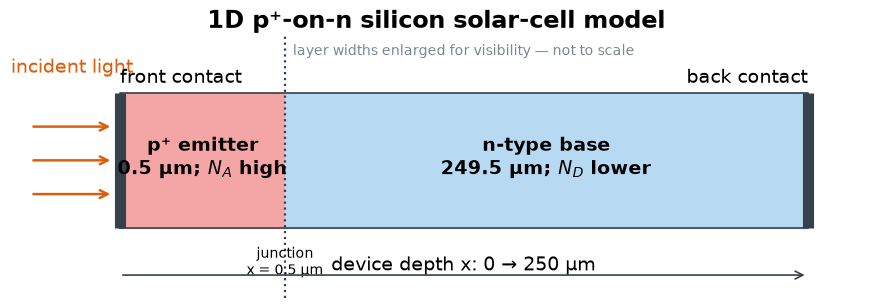

In [3]:
device_params = check_params({
    **MODEL_PARAMS, "series_resistance": 0.0, "shunt_resistance": 0.0
})  # internal profiles describe the intrinsic device
emitter_um = device_params.emitter_depth * 1e4
thickness_um = device_params.thickness * 1e4
display_junction = 0.24  # enlarged so the 0.5 µm emitter remains visible

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.fill_betweenx([0, 1], 0, display_junction, color="#f4a6a6")
ax.fill_betweenx([0, 1], display_junction, 1, color="#b7d9f2")
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color=C_DARK, lw=1.2)
ax.plot([0, 0], [0, 1], color=C_DARK, lw=8, solid_capstyle="butt")
ax.plot([1, 1], [0, 1], color=C_DARK, lw=8, solid_capstyle="butt")
ax.text(display_junction / 2, 0.52,
        f"p⁺ emitter\n{emitter_um:g} µm; $N_A$ high",
        ha="center", va="center", weight="bold")
ax.text((display_junction + 1) / 2, 0.52,
        f"n-type base\n{thickness_um - emitter_um:g} µm; $N_D$ lower",
        ha="center", va="center", weight="bold")
ax.axvline(display_junction, color=C_DARK, ls=":", lw=1.6)
ax.text(display_junction, -0.13, f"junction\nx = {emitter_um:g} µm",
        ha="center", va="top", fontsize=10)
for ypos in (0.25, 0.50, 0.75):
    ax.annotate("", xy=(-0.01, ypos), xytext=(-0.13, ypos),
                arrowprops=dict(arrowstyle="->", color=C_ORANGE, lw=1.8))
ax.text(-0.07, 1.15, "incident light", color=C_ORANGE, ha="center")
ax.annotate("", xy=(1, -0.35), xytext=(0, -0.35),
            arrowprops=dict(arrowstyle="->", color=C_DARK, lw=1.2))
ax.text(0.50, -0.35, f"device depth x: 0 → {thickness_um:g} µm",
        ha="center", va="bottom")
ax.text(0, 1.04, "front contact", ha="left", va="bottom")
ax.text(1, 1.04, "back contact", ha="right", va="bottom")
ax.text(0.50, 1.28, "layer widths enlarged for visibility — not to scale",
        color=C_GRAY, ha="center", fontsize=10)
ax.set_xlim(-0.16, 1.08)
ax.set_ylim(-0.52, 1.42)
ax.set_title("1D p⁺-on-n silicon solar-cell model")
ax.axis("off")
plt.show()


## 7. 内部物理量：短路状态

端口 J–V 只能告诉我们器件“做了什么”，内部剖面帮助解释“为什么”。下面只保留四个互补面板；能带单独放在下一幅图，避免信息重复。


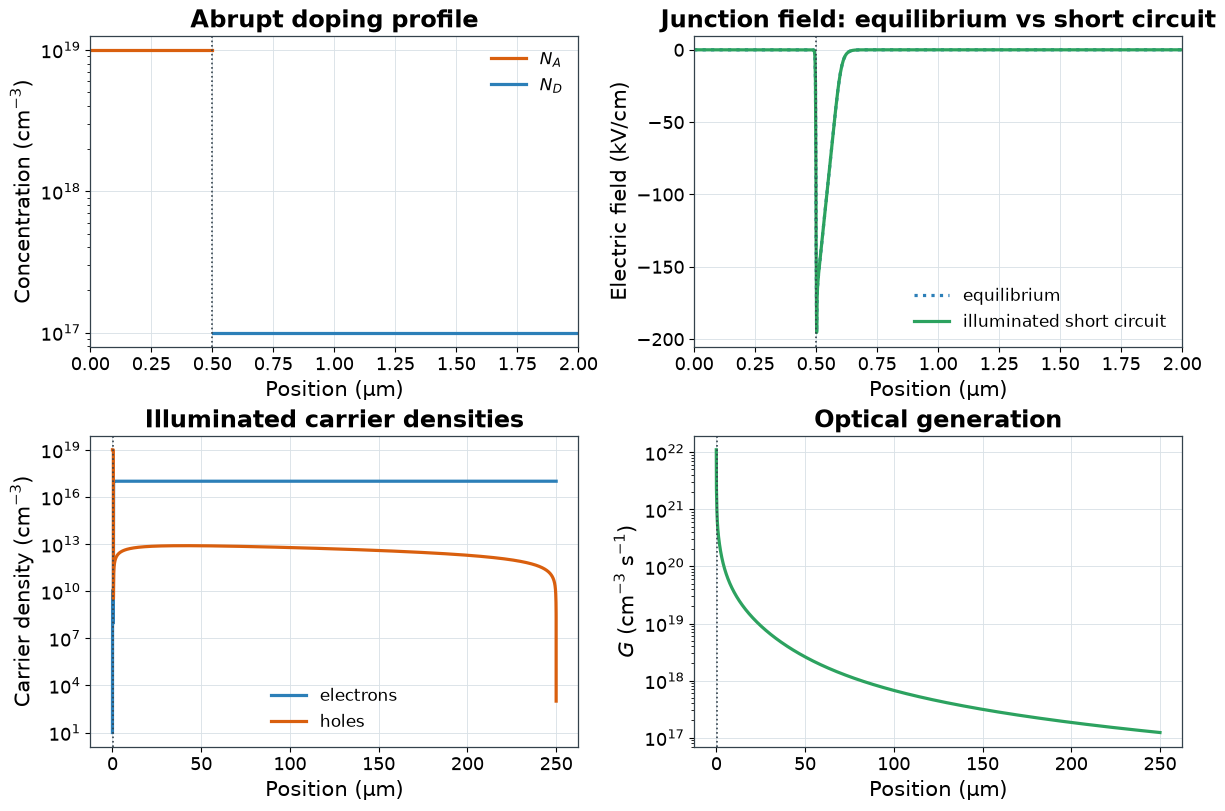

In [4]:
device_data = profiles(device_params, bias=0.0)
position_um = device_data["x"] * 1e4
junction_um = device_params.emitter_depth * 1e4
junction_zoom_um = 2.0
equilibrium_field = -np.gradient(device_data["potential"], device_data["x"])
short_circuit_field = -np.gradient(device_data["ill_potential"], device_data["x"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.semilogy(position_um, np.where(device_data["acceptors"] > 0, device_data["acceptors"], np.nan),
            color=C_ORANGE, label="$N_A$")
ax.semilogy(position_um, np.where(device_data["donors"] > 0, device_data["donors"], np.nan),
            color=C_BLUE, label="$N_D$")
ax.set(xlabel="Position (µm)", ylabel="Concentration (cm$^{-3}$)", title="Abrupt doping profile")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.plot(position_um, equilibrium_field / 1e3, color=C_BLUE, ls=":", label="equilibrium")
ax.plot(position_um, short_circuit_field / 1e3, color=C_GREEN, label="illuminated short circuit")
ax.set(xlabel="Position (µm)", ylabel="Electric field (kV/cm)",
       title="Junction field: equilibrium vs short circuit")
ax.legend(frameon=False)
for ax in axes[0, :]:
    ax.set_xlim(0, junction_zoom_um)

ax = axes[1, 0]
ax.semilogy(position_um, device_data["ill_electrons"], color=C_BLUE, label="electrons")
ax.semilogy(position_um, device_data["ill_holes"], color=C_ORANGE, label="holes")
ax.set(xlabel="Position (µm)", ylabel="Carrier density (cm$^{-3}$)", title="Illuminated carrier densities")
ax.legend(frameon=False)

ax = axes[1, 1]
ax.semilogy(position_um, np.maximum(device_data["generation"], 1e-30), color=C_GREEN)
ax.set(xlabel="Position (µm)", ylabel="$G$ (cm$^{-3}$ s$^{-1}$)", title="Optical generation")

for ax in axes.flat:
    ax.axvline(junction_um, color=C_DARK, ls=":", lw=1.2)
    ax.grid(True)
plt.show()


Built-in potential from the electrostatic solution: 0.9537 V


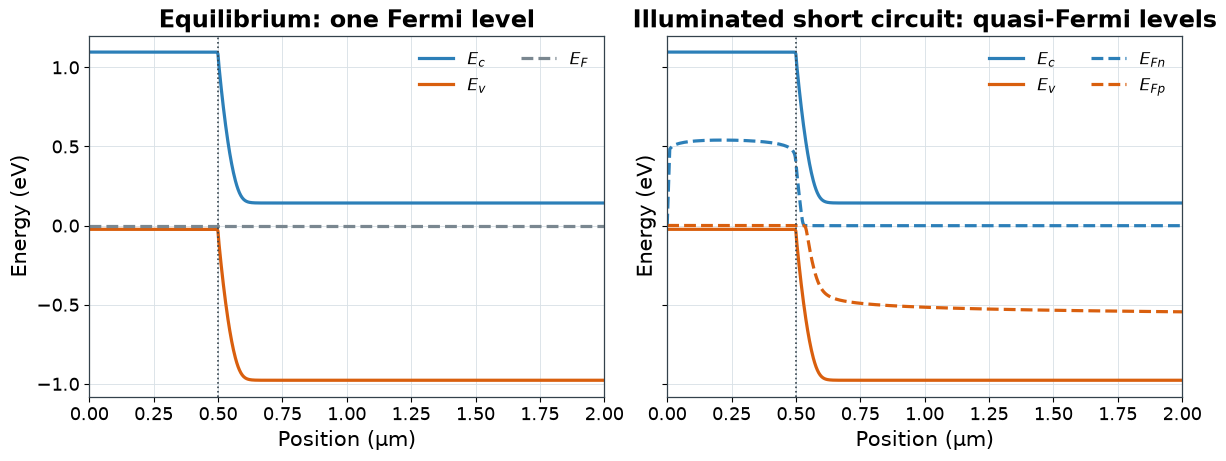

In [5]:
eq_bands = band_edges(
    device_data["potential"], device_data["electrons"], device_data["holes"],
    device_params.temperature,
)
lit_bands = band_edges(
    device_data["ill_potential"], device_data["ill_electrons"], device_data["ill_holes"],
    device_params.temperature,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True, sharey=True)
axes[0].plot(position_um, eq_bands[0], color=C_BLUE, label="$E_c$")
axes[0].plot(position_um, eq_bands[1], color=C_ORANGE, label="$E_v$")
axes[0].axhline(0, color=C_GRAY, ls="--", label="$E_F$")
axes[0].set_title("Equilibrium: one Fermi level")

axes[1].plot(position_um, lit_bands[0], color=C_BLUE, label="$E_c$")
axes[1].plot(position_um, lit_bands[1], color=C_ORANGE, label="$E_v$")
axes[1].plot(position_um, lit_bands[2], "--", color=C_BLUE, label="$E_{Fn}$")
axes[1].plot(position_um, lit_bands[3], "--", color=C_ORANGE, label="$E_{Fp}$")
axes[1].set_title("Illuminated short circuit: quasi-Fermi levels")

for ax in axes:
    ax.axvline(junction_um, color=C_DARK, ls=":", lw=1.2)
    ax.set_xlim(0, junction_zoom_um)
    ax.set(xlabel="Position (µm)", ylabel="Energy (eV)")
    ax.legend(frameon=False, ncol=2)
    ax.grid(True)

left_index = int(np.argmin(np.abs(position_um - 0.1)))
right_index = int(np.argmin(np.abs(position_um - min(10.0, thickness_um - 1.0))))
built_in_voltage_model = (
    device_data["potential"][right_index] - device_data["potential"][left_index]
)
print(f"Built-in potential from the electrostatic solution: {built_in_voltage_model:.4f} V")
plt.show()


## 8. J–V 特性与性能指标

这里使用电流密度 $J$，所以称为 **J–V**；Keithley 原始文件记录总电流 $I$，应称为 **I–V**。在 generation-positive 约定下：$J(0)=J_{sc}>0$，开路点满足 $J(V_{oc})=0$，发电象限的功率密度为 $P=VJ>0$。16 个光学 bin 近似驱动光生的带隙以上光子；示意效率另行声明 100 mW/cm² 总模拟输入，其中包含未进入光生 bin 的光谱功率。


Jsc  = 29.34 mA/cm^2
Voc  = 0.6147 V
FF   = 0.830
Pmax = 14.96 mW/cm^2
Illustrative modeled efficiency at 100 mW/cm^2 = 14.96%


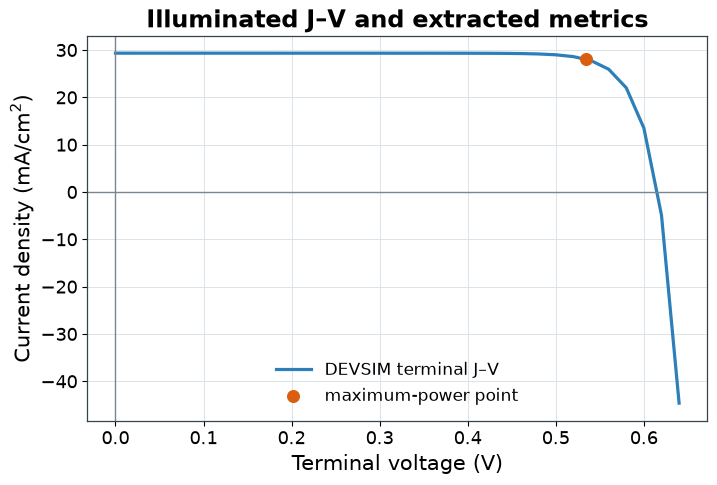

In [6]:
voltage, current_density = terminal_iv(MODEL_PARAMS)
modeled_pin = MODELED_INPUT_POWER_W_CM2 * device_params.photon_flux
metrics = solar_metrics(voltage, current_density, pin=modeled_pin)

print(f"Jsc  = {metrics['Jsc'] * 1e3:.2f} mA/cm^2")
print(f"Voc  = {metrics['Voc']:.4f} V")
print(f"FF   = {metrics['FF']:.3f}")
print(f"Pmax = {metrics['Pmax'] * 1e3:.2f} mW/cm^2")
print(f"Illustrative modeled efficiency at {modeled_pin * 1e3:.0f} mW/cm^2 = "
      f"{metrics['eta'] * 100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(voltage, current_density * 1e3, color=C_BLUE, label="DEVSIM terminal J–V")
ax.scatter(metrics["Vmp"], metrics["Jmp"] * 1e3, color=C_ORANGE, s=70,
           zorder=3, label="maximum-power point")
ax.axhline(0, color=C_GRAY, lw=1)
ax.axvline(0, color=C_GRAY, lw=1)
ax.set(xlabel="Terminal voltage (V)", ylabel="Current density (mA/cm$^2$)",
       title="Illuminated J–V and extracted metrics")
ax.grid(True)
ax.legend(frameon=False)
plt.show()


## 9. 灵敏度：参数变化是否能被端口数据看见？

参数只有在观测量对它足够敏感时才可能被可靠校准。以下只扫描 n 型基区少数载流子（空穴）寿命，建立“参数 → J–V 指标”的直觉。注意：寿命、表面复合和光学损失可能产生相似影响，因此灵敏并不等于可唯一辨识。


,hole_lifetime_s,Jsc_mA_cm2,Voc_V
0,1.00e-06,26.32,0.6052
1,3.16e-06,28.09,0.6106
2,1.00e-05,29.34,0.6147
3,3.16e-05,30.03,0.6170
4,1.00e-04,30.31,0.6181


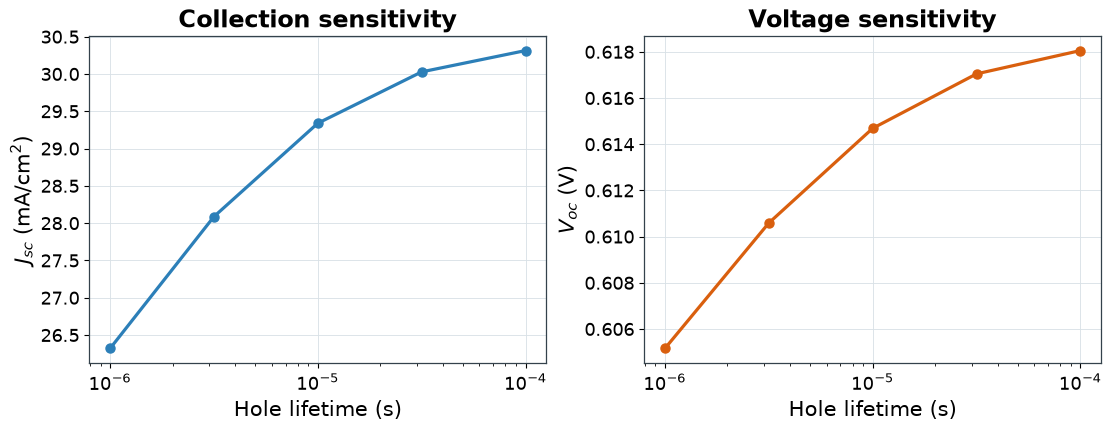

In [7]:
lifetimes = np.geomspace(1e-6, 1e-4, 5)
sensitivity_rows = []
for lifetime in lifetimes:
    sweep_params = {**MODEL_PARAMS, "hole_lifetime": float(lifetime)}
    sweep_voltage, sweep_current = terminal_iv(params=sweep_params)
    sweep_metrics = solar_metrics(sweep_voltage, sweep_current, pin=None)
    sensitivity_rows.append(
        (lifetime, sweep_metrics["Jsc"] * 1e3, sweep_metrics["Voc"])
    )

sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=["hole_lifetime_s", "Jsc_mA_cm2", "Voc_V"],
)
sensitivity_table = sensitivity.assign(
    hole_lifetime_s=lambda frame: frame["hole_lifetime_s"].map("{:.2e}".format),
    Jsc_mA_cm2=lambda frame: frame["Jsc_mA_cm2"].map("{:.2f}".format),
    Voc_V=lambda frame: frame["Voc_V"].map("{:.4f}".format),
)
display(sensitivity_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].semilogx(sensitivity["hole_lifetime_s"], sensitivity["Jsc_mA_cm2"],
                 "o-", color=C_BLUE)
axes[0].set(xlabel="Hole lifetime (s)", ylabel="$J_{sc}$ (mA/cm$^2$)",
            title="Collection sensitivity")
axes[1].semilogx(sensitivity["hole_lifetime_s"], sensitivity["Voc_V"],
                 "o-", color=C_ORANGE)
axes[1].set(xlabel="Hole lifetime (s)", ylabel="$V_{oc}$ (V)",
            title="Voltage sensitivity")
for ax in axes:
    ax.grid(True)
plt.show()


## 10. 数据来源：raw、processed 与 synthetic

- `data/raw/keithley/`：Keithley 2636B 的**历史课堂实验导出**，保留仪器格式和元数据；不是当前学生刚测的数据。
- `data/processed/`：用已记录的 4.0 cm² 有效面积及明确的电压/电流极性转换得到的标准表；列 `V`、`J` 的单位分别为 V、A/cm²。
- `data/synthetic/`：由模型生成，只用于无硬件练习、测试优化器和检查代码。

原始文件是 I–V；除以有效面积后才是 J–V。处理不能“猜”符号、面积或辐照度。本仓库未提供经校准的电池平面辐照度记录，因此不能据此计算实验效率。


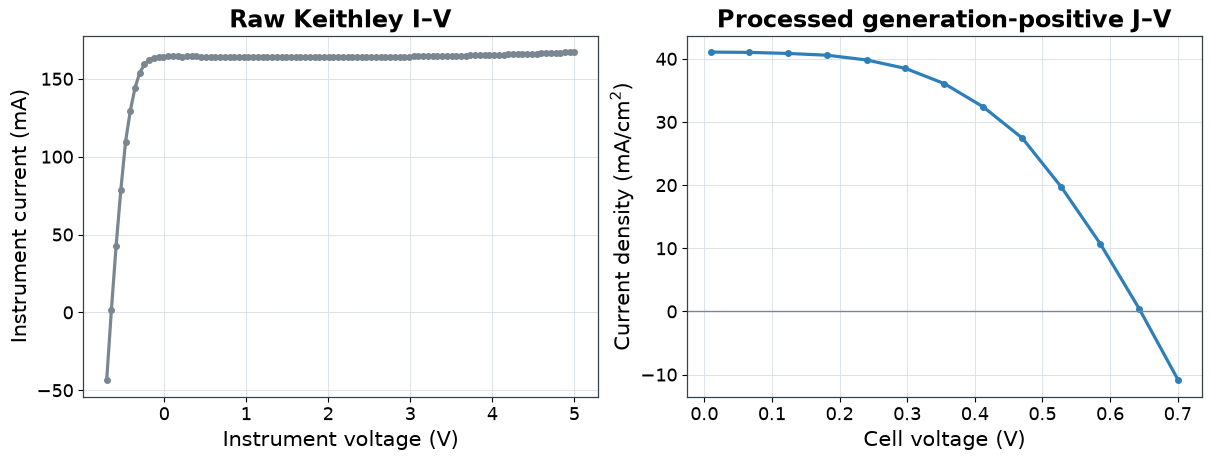

,sample,condition,J_mean_A_cm2,J_std_A_cm2,V_mean_V,V_std_V,n_points,V_at_I0_V
0,3,dark,0.000103,0.000001,0.000029,0.000004,100,0.228402
1,3,light,0.040459,0.000074,-0.000017,0.000004,100,0.643771


In [8]:
from scripts.prepare_keithley import parse_keithley

raw_path = Path("data/raw/keithley/light - iv -3.csv")
processed_path = Path("data/processed/light_iv_sample3.csv")
raw_voltage, raw_current = parse_keithley(raw_path)
processed = pd.read_csv(processed_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(raw_voltage, raw_current * 1e3, "o-", color=C_GRAY, ms=4)
axes[0].set(xlabel="Instrument voltage (V)", ylabel="Instrument current (mA)",
            title="Raw Keithley I–V")
axes[1].plot(processed["V"], processed["J"] * 1e3, "o-", color=C_BLUE, ms=4)
axes[1].axhline(0, color=C_GRAY, lw=1)
axes[1].set(xlabel="Cell voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Processed generation-positive J–V")
for ax in axes:
    ax.grid(True)
plt.show()

short_summary = pd.read_csv("data/processed/ishort_summary.csv")
voc_summary = pd.read_csv("data/processed/voc_summary.csv")
cell3_summary = short_summary.query("sample == 3").merge(
    voc_summary.query("sample == 3"), on=["sample", "condition"]
)
display(cell3_summary)


## 11. 先用合成 J–V 理解优化器

先在已知来源的 `data/synthetic/iv.csv` 上观察优化过程，可将“代码是否工作”与“真实器件是否被完整建模”分开。橙色点在这里是**合成参考数据**，不是实验测量。优化器调整有效光生强度和串联电阻，使归一化残差平方和下降。


Starting the synthetic J–V calibration trace...


Converged after 54 evaluations and recorded 49 distinct states; final objective = 0.001343.


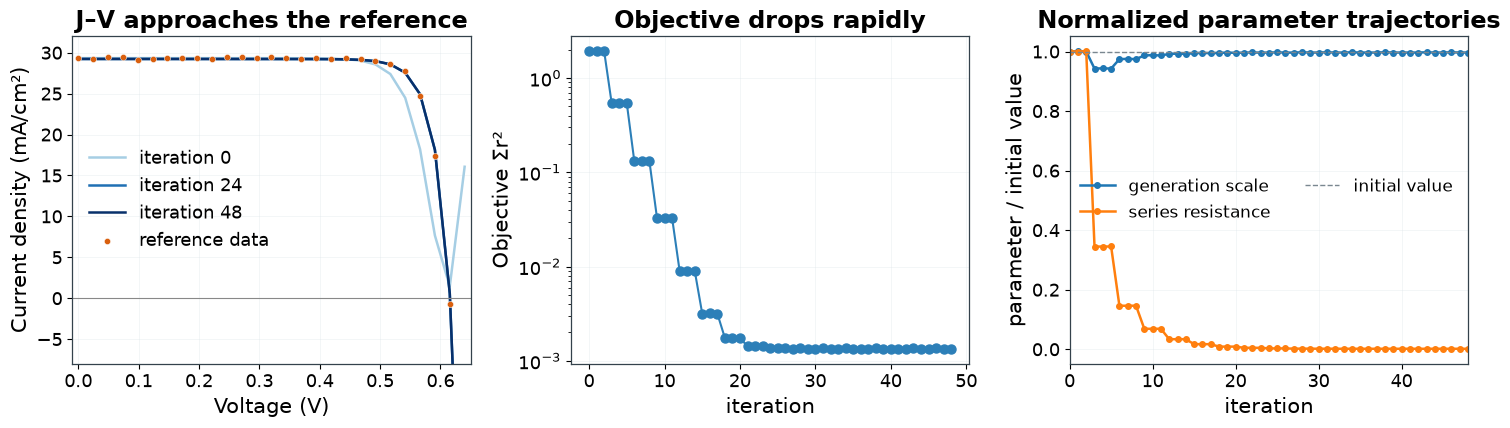

In [9]:
from calibration.fit import load_iv_csv, make_params
from calibration.trace import fit_with_trace, plot_optimization_trace

synthetic_voltage, synthetic_current = load_iv_csv("data/synthetic/iv.csv")
fit_parameters = make_params()
print("Starting the synthetic J–V calibration trace...")
trace_names, optimization_trace, synthetic_result = fit_with_trace(
    synthetic_voltage,
    synthetic_current,
    params=fit_parameters,
    max_nfev=60,
)
if not synthetic_result.success:
    raise RuntimeError(f"Synthetic calibration did not converge: {synthetic_result.message}")
print(
    f"Converged after {synthetic_result.nfev} evaluations and "
    f"recorded {len(optimization_trace)} distinct states; "
    f"final objective = {optimization_trace[-1]['chisq']:.4g}."
)
optimization_figure = plot_optimization_trace(
    trace_names, optimization_trace, synthetic_voltage, synthetic_current
)
display(optimization_figure)
plt.close(optimization_figure)


## 12. Cell #3 联合校准：让不同数据约束不同物理

正式示例使用同一 Cell #3 的四类历史观测：

| 观测 | 主要信息 | 在目标函数中的处理 |
|---|---|---|
| light J–V | 光生电流、曲线形状、串联损失 | 按电流尺度归一化的 RMS block |
| dark J–V | 二极管/泄漏交叉检查，对有效串联电阻有限约束 | 独立 RMS block |
| light $J_{sc}$ 重复测量 | 近零偏压电流密度与重复性 | 均值 + 不确定度下限 |
| light $V_{oc}$ | 零电流条件 | 在实测 $V_{oc}$ 处约束模型电流 |

各 block 先用可解释的 discrepancy scale 无量纲化，再施加教学权重，避免“采样点较多的数据自动占据全部目标函数”。为控制课堂运行时间，优化目标在实测点计算端口电路方程残差；最终曲线与 RMSE 则由自洽端口 J–V 重新计算。精确拟合时两者一致，有系统失配时应优先解释最终曲线和 RMSE。本练习只拟合光生强度与有效串联电阻；dark 曲线主要是交叉检查，不代表已辨识寿命、SRV 或详细二极管物理。dark 条件下记录的零电流电压只作为仪器偏置诊断，不当作暗态物理 $V_{oc}$。


Cell #3: 13 light J–V points and 15 dark J–V points
Independent light Jsc check: 40.459 mA/cm^2
Independent light Voc check: 0.6438 V


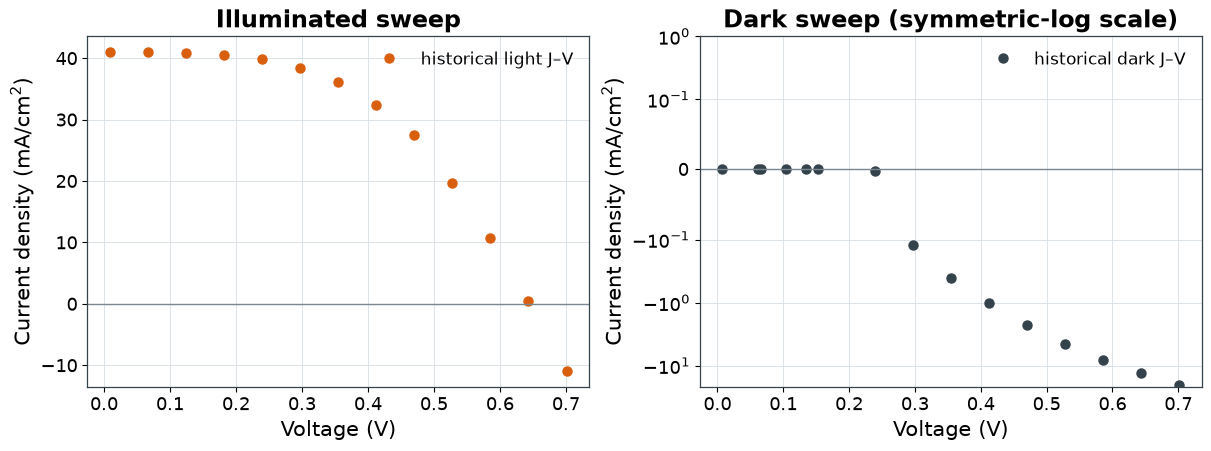

In [10]:
from calibration.fit import load_joint_data

joint_data = load_joint_data(3)
print(f"Cell #{joint_data.sample}: {len(joint_data.light_v)} light J–V points and "
      f"{len(joint_data.dark_v)} dark J–V points")
print(f"Independent light Jsc check: {joint_data.light_ishort['J_mean_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Independent light Voc check: {joint_data.light_voc:.4f} V")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
axes[0].plot(joint_data.light_v, joint_data.light_j * 1e3, "o", color=C_ORANGE,
             label="historical light J–V")
axes[0].axhline(0, color=C_GRAY, lw=1)
axes[0].set(xlabel="Voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Illuminated sweep")
axes[0].legend(frameon=False)
axes[1].plot(joint_data.dark_v, joint_data.dark_j * 1e3, "o", color=C_DARK,
             label="historical dark J–V")
axes[1].axhline(0, color=C_GRAY, lw=1)
axes[1].set_yscale("symlog", linthresh=0.1)
axes[1].set(xlabel="Voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Dark sweep (symmetric-log scale)")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(True)
plt.show()


In [11]:
from calibration.fit import evaluate_joint, fit_joint, joint_block_score

print("Starting the Cell #3 joint calibration...")
joint_result = fit_joint(joint_data)
if not joint_result.success:
    raise RuntimeError(f"Joint calibration failed: {joint_result.message}")
joint_metrics = evaluate_joint(joint_result.params, joint_data)

print("Fitted effective parameters:")
for name in ("photon_flux", "series_resistance"):
    parameter = joint_result.params[name]
    uncertainty = "unavailable" if parameter.stderr is None else f"{parameter.stderr:.3g}"
    print(f"  {name}: {parameter.value:.5g} (standard error: {uncertainty})")
print(f"Light J–V RMSE: {joint_metrics['light_iv_rmse_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Dark J–V RMSE: {joint_metrics['dark_iv_rmse_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Light Voc error: {joint_metrics['light_voc_error_V'] * 1e3:+.2f} mV")
block_score = joint_block_score(joint_result.chisqr, joint_data)
print(f"Normalized block score: {block_score:.3f} (1 = stated scales; 4 = twice-scale RMS)")
quality_limit = CALIBRATION["joint"].get("quality_warning_block_score", 4.0)
if block_score > quality_limit:
    print("WARNING: systematic model-data mismatch exceeds the teaching discrepancy scales.")


Starting the Cell #3 joint calibration...


Fitted effective parameters:
  photon_flux: 1.5483 (standard error: 0.0197)
  series_resistance: 4.938 (standard error: 0.0577)
Light J–V RMSE: 4.185 mA/cm^2
Dark J–V RMSE: 1.677 mA/cm^2
Light Voc error: -16.48 mV
Normalized block score: 280.801 (1 = stated scales; 4 = twice-scale RMS)


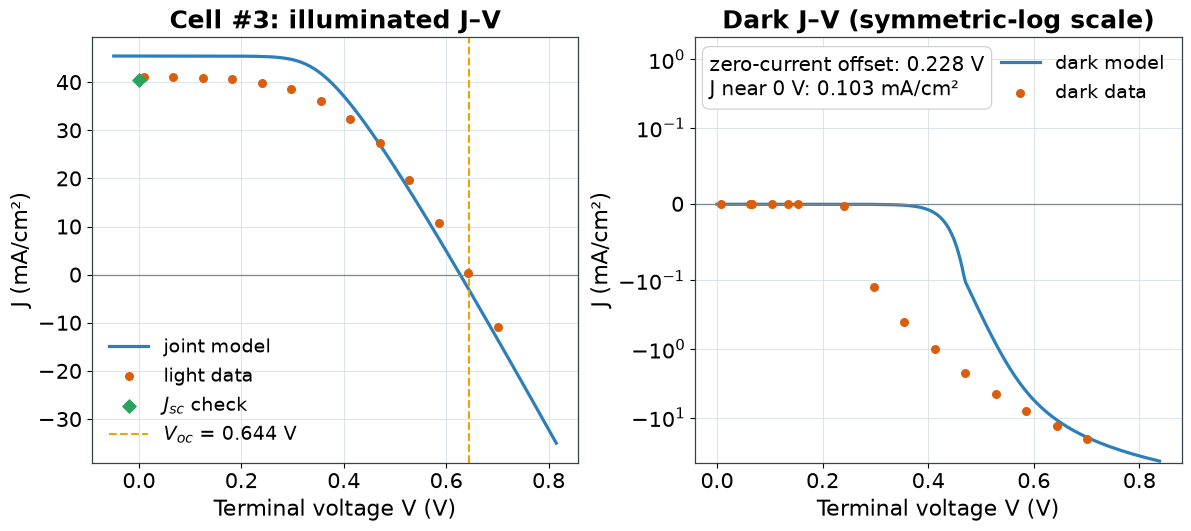

In [12]:
from calibration.report import joint_comparison_figure

joint_params = {**MODEL_PARAMS, **joint_result.params.valuesdict()}
joint_figure = joint_comparison_figure(joint_data, joint_params)
display(joint_figure)
plt.close(joint_figure)


## 13. 拟合得好，不等于参数一定可信

局部协方差回答的是：在当前模型、当前数据、当前权重和最优点附近，参数小幅变化能否被区分。相对不确定度较大或参数高度相关时，应报告“有效参数/弱约束”，而不是给出过度精确的材料结论。即使相对不确定度较小，只要联合曲线仍有系统失配，它也只能表示局部数值敏感性，不能证明模型充分或参数物理真实。加入更多同类采样点通常不如加入物理信息互补的观测有效。


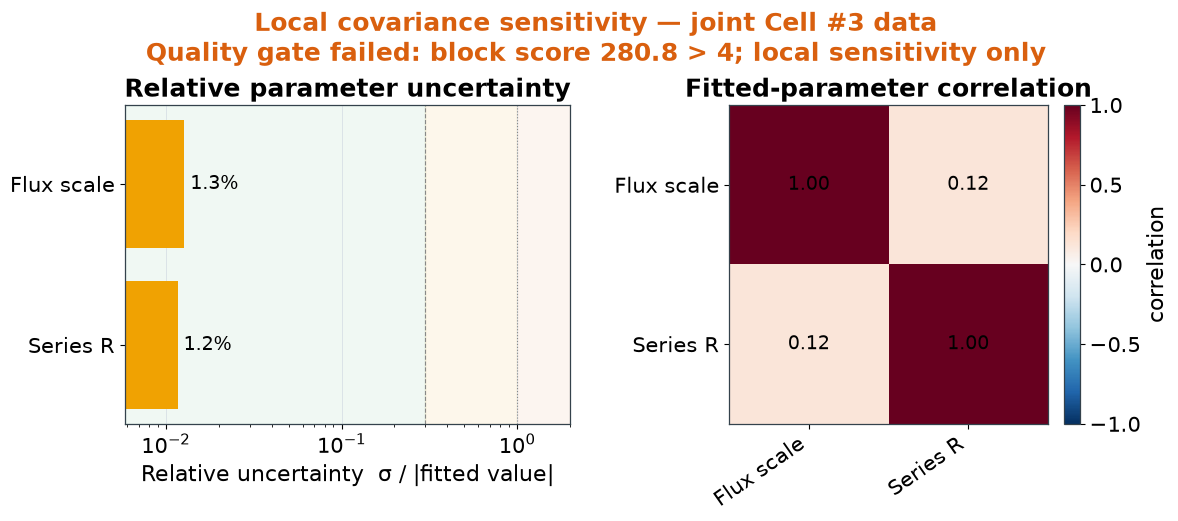

Local covariance sensitivity (quality gate failed):
  photon_flux: stderr/abs(value) = 1.28% -> local numerical sensitivity only (quality gate failed)
  series_resistance: stderr/abs(value) = 1.17% -> local numerical sensitivity only (quality gate failed)


In [13]:
from calibration.report import identifiability_figure, identifiability_summary

joint_names = getattr(joint_result, "var_names", None) or [
    name for name, parameter in joint_result.params.items() if parameter.vary
]
joint_covariance = getattr(joint_result, "covar", None)
quality_note = None if block_score <= quality_limit else (
    f"Quality gate failed: block score {block_score:.1f} > {quality_limit:g}; "
    "local sensitivity only"
)
identifiability = identifiability_figure(
    joint_result.params,
    covar=joint_covariance,
    var_names=joint_names,
    context="joint Cell #3 data",
    quality_note=quality_note,
)
display(identifiability)
plt.close(identifiability)
quality_adequate = block_score <= quality_limit
heading = ("Parameter identifiability" if quality_adequate else
           "Local covariance sensitivity (quality gate failed)")
print(f"{heading}:")
for line in identifiability_summary(
    joint_result.params, covar=joint_covariance, var_names=joint_names,
    quality_adequate=quality_adequate,
):
    print(f"  {line}")


## 14. External quantum efficiency (EQE)

$$\mathrm{EQE}(\lambda)=\frac{\text{collected electrons per second}}{\text{incident photons per second at }\lambda}.$$

下面的曲线完全来自 DEVSIM 单色短路仿真，并与“仅考虑吸收、假设每个被吸收光子都被收集”的上限比较；**没有伪装成测量值的合成散点**。本课程项目不要求额外 EQE 实验数据：若实验室确实测得光谱响应，可再以独立 CSV 作为验证数据，而不是把它并入默认示例。

这里的 16-bin AM1.5-like 光谱是教学近似，不是可替代 ASTM 标准光谱的计量数据。


EQE-integrated Jsc = 29.34 mA/cm^2
Full-spectrum Jsc  = 29.34 mA/cm^2
Relative mismatch  = 0.00%


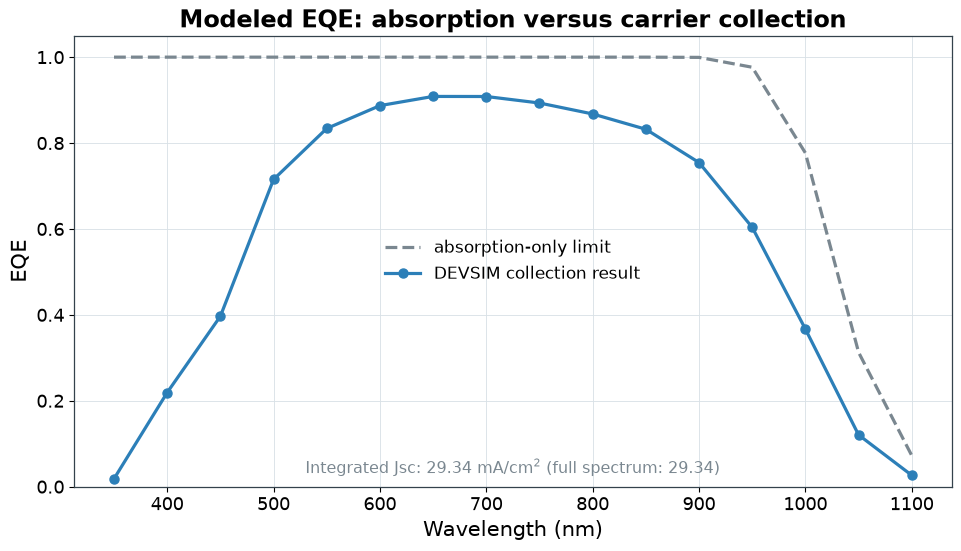

In [14]:
from model.spectrum import absorption_cm, bin_photon_flux, wavelengths_nm

wavelengths = wavelengths_nm()
absorption = absorption_cm()
eqe_params = check_params({**MODEL_PARAMS, "series_resistance": 0.0, "shunt_resistance": 0.0})
electron_charge = 1.602176634e-19

modeled_eqe = np.array([
    simulate_eqe(eqe_params, index)
    / (electron_charge * eqe_params.photon_flux * bin_photon_flux(index))
    for index in range(len(wavelengths))
])
absorption_limit = (
    (1 - eqe_params.front_reflectance)
    * (1 - np.exp(-absorption * eqe_params.thickness))
)

photon_bins = np.array([bin_photon_flux(index) for index in range(len(wavelengths))])
eqe_integrated_jsc = (
    electron_charge * eqe_params.photon_flux * np.sum(modeled_eqe * photon_bins)
)
_, full_spectrum_current = run_simulation(
    params=dict(vars(eqe_params)), voltages=np.array([0.0])
)
full_spectrum_jsc = float(full_spectrum_current[0])
print(f"EQE-integrated Jsc = {eqe_integrated_jsc * 1e3:.2f} mA/cm^2")
print(f"Full-spectrum Jsc  = {full_spectrum_jsc * 1e3:.2f} mA/cm^2")
print(f"Relative mismatch  = {abs(eqe_integrated_jsc - full_spectrum_jsc) / abs(full_spectrum_jsc):.2%}")

fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
ax.plot(wavelengths, absorption_limit, "--", color=C_GRAY,
        label="absorption-only limit")
ax.plot(wavelengths, modeled_eqe, "o-", color=C_BLUE,
        label="DEVSIM collection result")
ax.set(xlabel="Wavelength (nm)", ylabel="EQE",
       title="Modeled EQE: absorption versus carrier collection")
ax.set_ylim(0, 1.05)
ax.grid(True)
ax.legend(frameon=False)
ax.text(0.5, 0.03,
        f"Integrated Jsc: {eqe_integrated_jsc * 1e3:.2f} mA/cm$^2$ "
        f"(full spectrum: {full_spectrum_jsc * 1e3:.2f})",
        transform=ax.transAxes, ha="center", color=C_GRAY, fontsize=11.5)
plt.show()


## 15. Model scope and limitations

解读结果时必须同时写清模型边界：

- **结构：** 1D abrupt p⁺-on-n；不含纹理、指栅遮挡、横向电流或工艺扩散轮廓。
- **输运与复合：** 恒定低场迁移率、SRH + Auger；表面复合以有效 dead layer 表示。
- **光学：** 16-bin AM1.5-like 教学输入与 Beer–Lambert 吸收；未包含完整薄膜干涉。
- **端口：** $R_s$、$R_{sh}$ 是面积归一的有效后处理参数，不应直接解释为某一层的材料常数。
- **实验：** 预置 Cell #3/#4 是历史示例。学生应保留自己的 raw 数据、记录面积与极性；没有独立辐照度时不要报告效率。
- **校准：** 好的残差只能说明模型在所选观测上接近数据，不能证明所有内部参数都真实或唯一。


## 16. 总结与下一步

你已经完成一条可复现的闭环：

1. 用 p⁺-on-n 结构、Poisson 与漂移—扩散方程定义前向模型；
2. 用 Newton 演示理解非线性求解，并用内部剖面与能带解释 J–V；
3. 明确 raw I–V、processed J–V、synthetic data 与历史测量的边界；
4. 先用合成数据理解优化器，再用 Cell #3 的多类实验观测联合校准；
5. 用不确定度和相关性判断“哪些结论可由数据支持”。

下一步只需替换为你自己的原始测量，按实验记录重新运行数据处理与校准，并在报告中解释：**哪些参数改变了、哪些观测约束了它们、模型仍遗漏了什么。**
